# Sales Data Analysis
Visualisations basées sur `orders_enriched.parquet` et `sales_summary.parquet`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

orders = pd.read_parquet("../data/processed/orders_enriched.parquet")
summary = pd.read_parquet("../data/processed/sales_summary.parquet")

summary["period"] = summary["order_year_month"].astype(str)

print(f"orders_enriched : {len(orders)} lignes")
print(f"sales_summary   : {len(summary)} lignes")
orders.head(3)

orders_enriched : 30 lignes
sales_summary   : 8 lignes


,order_id,customer_id,product_id,quantity,order_date,status,discount_pct,full_name,city,country,signup_date,name,category,unit_price,gross_revenue,discount_amount,net_revenue,estimated_cost,gross_profit,order_year_month
0,O001,C001,P001,1,2024-01-05,delivered,0.05,Alice Martin,Paris,France,2022-01-15,Laptop Pro 15,Electronics,1299.99,1299.99,64.9995,1234.9905,909.993,324.9975,2024-01
1,O002,C002,P002,2,2024-01-07,delivered,0.00,Bob Dupont,Lyon,France,2022-03-22,Wireless Mouse,Electronics,29.99,59.98,0.0000,59.9800,41.986,17.9940,2024-01
2,O003,C003,P007,1,2024-01-10,shipped,0.10,Clara Smith,London,UK,2022-05-10,"Monitor 27""",Electronics,349.99,349.99,34.9990,314.9910,244.993,69.9980,2024-01


## 1. Chiffre d'affaires net mensuel

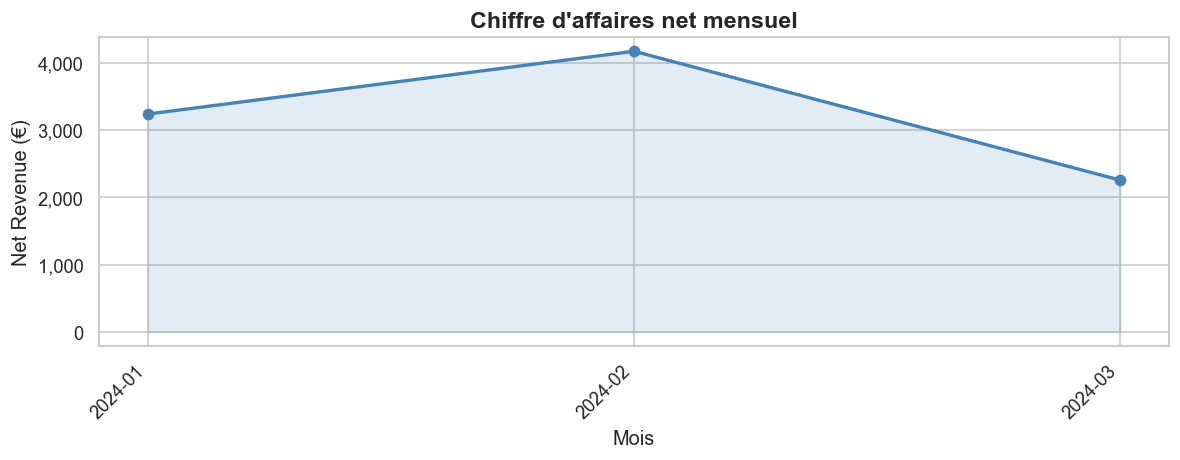

In [3]:
monthly = summary.groupby("period", sort=True)["net_revenue"].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly["period"], monthly["net_revenue"], marker="o", linewidth=2, color="steelblue")
ax.fill_between(monthly["period"], monthly["net_revenue"], alpha=0.15, color="steelblue")
ax.set_title("Chiffre d'affaires net mensuel", fontsize=14, fontweight="bold")
ax.set_xlabel("Mois")
ax.set_ylabel("Net Revenue (€)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 2. Revenue net et profit brut par catégorie

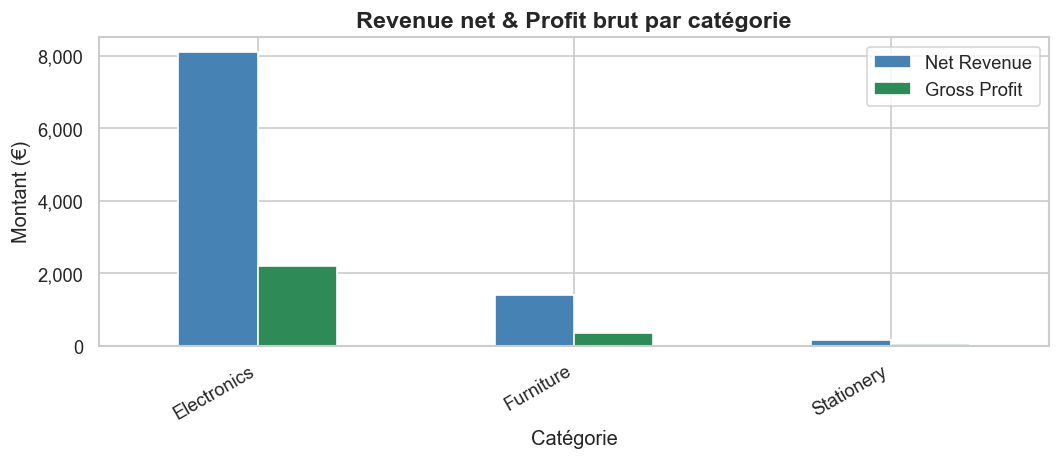

In [4]:
by_cat = summary.groupby("category")[["net_revenue", "gross_profit"]].sum().sort_values("net_revenue", ascending=False)

by_cat.plot(kind="bar", figsize=(9, 4), color=["steelblue", "seagreen"], edgecolor="white")
plt.title("Revenue net & Profit brut par catégorie", fontsize=14, fontweight="bold")
plt.xlabel("Catégorie")
plt.ylabel("Montant (€)")
plt.xticks(rotation=30, ha="right")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.legend(["Net Revenue", "Gross Profit"])
plt.tight_layout()
plt.show()

## 3. Distribution des statuts de commandes

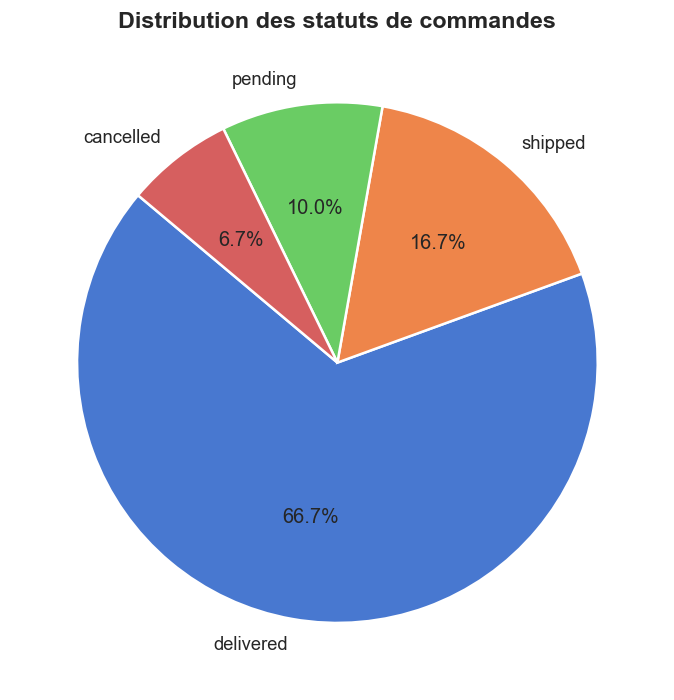

In [5]:
status_counts = orders["status"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("muted", len(status_counts)),
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
ax.set_title("Distribution des statuts de commandes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Marge bénéficiaire (%) par catégorie et par mois

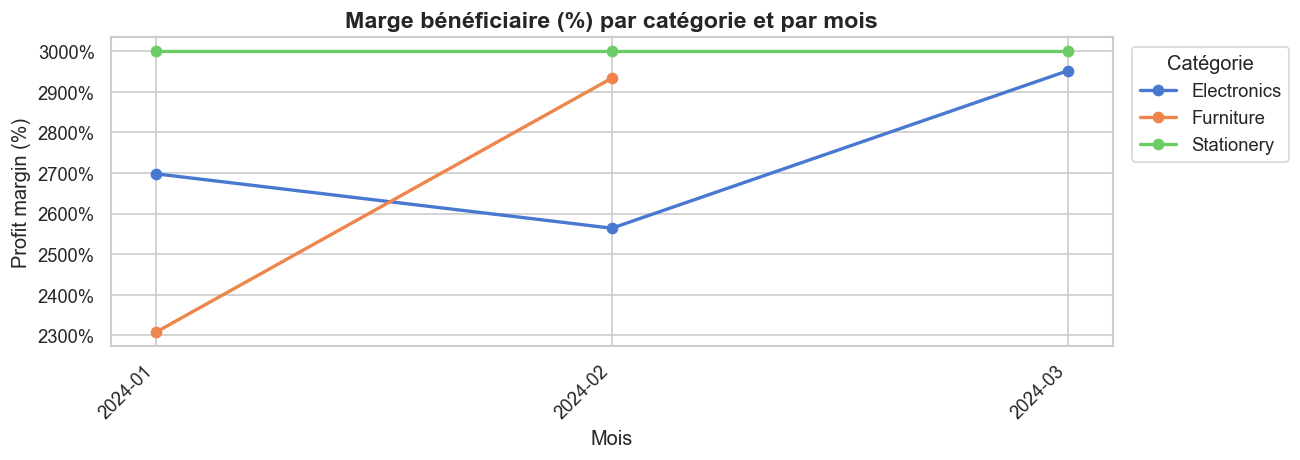

In [6]:
pivot = summary.pivot_table(index="period", columns="category", values="profit_margin_pct", aggfunc="mean")

fig, ax = plt.subplots(figsize=(11, 4))
for col in pivot.columns:
    ax.plot(pivot.index, pivot[col], marker="o", label=col, linewidth=2)
ax.set_title("Marge bénéficiaire (%) par catégorie et par mois", fontsize=14, fontweight="bold")
ax.set_xlabel("Mois")
ax.set_ylabel("Profit margin (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.xticks(rotation=45, ha="right")
plt.legend(title="Catégorie", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 5. Top 10 clients par revenue net

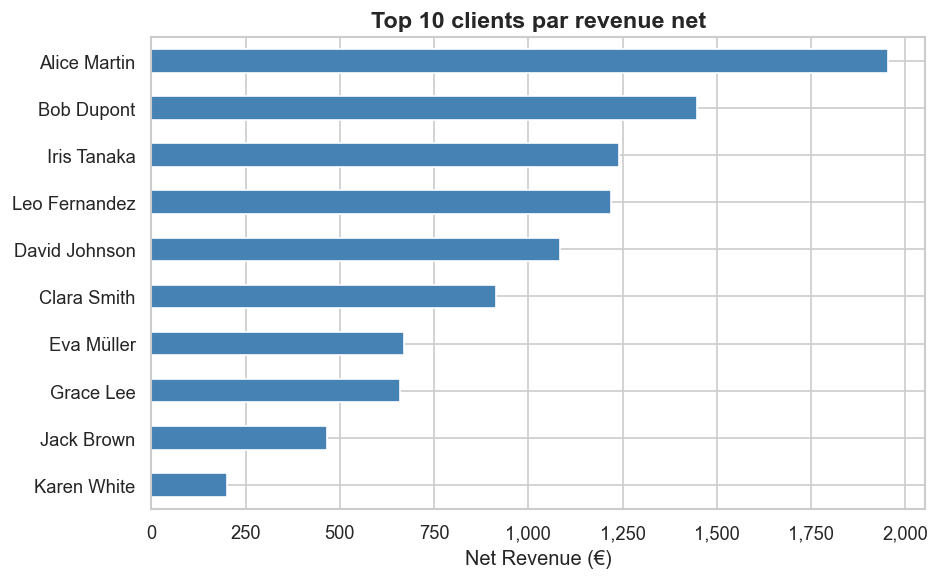

In [7]:
top_customers = (
    orders.groupby("full_name")["net_revenue"]
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

fig, ax = plt.subplots(figsize=(8, 5))
top_customers.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top 10 clients par revenue net", fontsize=14, fontweight="bold")
ax.set_xlabel("Net Revenue (€)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

## 6. Distribution des remises (discount_pct)

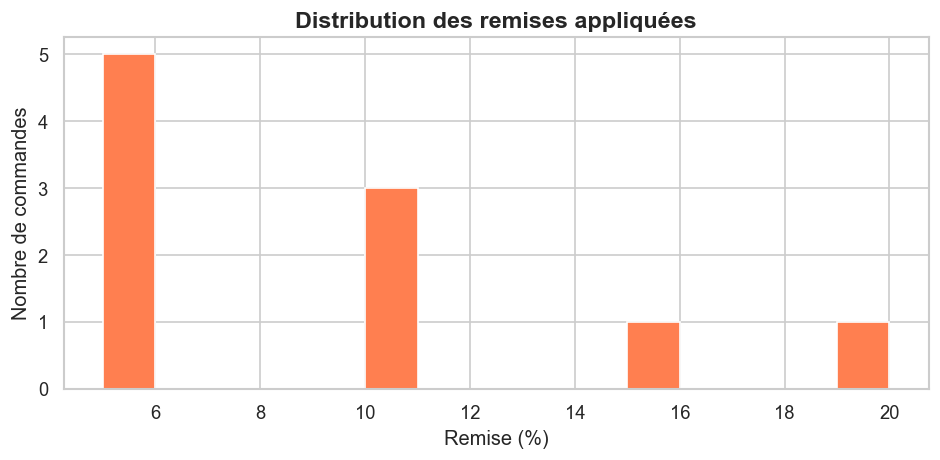

Commandes avec remise : 10 / 30 (33.3%)


In [8]:
discounted = orders[orders["discount_pct"] > 0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(discounted["discount_pct"] * 100, bins=15, color="coral", edgecolor="white")
ax.set_title("Distribution des remises appliquées", fontsize=14, fontweight="bold")
ax.set_xlabel("Remise (%)")
ax.set_ylabel("Nombre de commandes")
plt.tight_layout()
plt.show()
print(f"Commandes avec remise : {len(discounted)} / {len(orders)} ({len(discounted)/len(orders)*100:.1f}%)")

## 7. Revenue net par pays

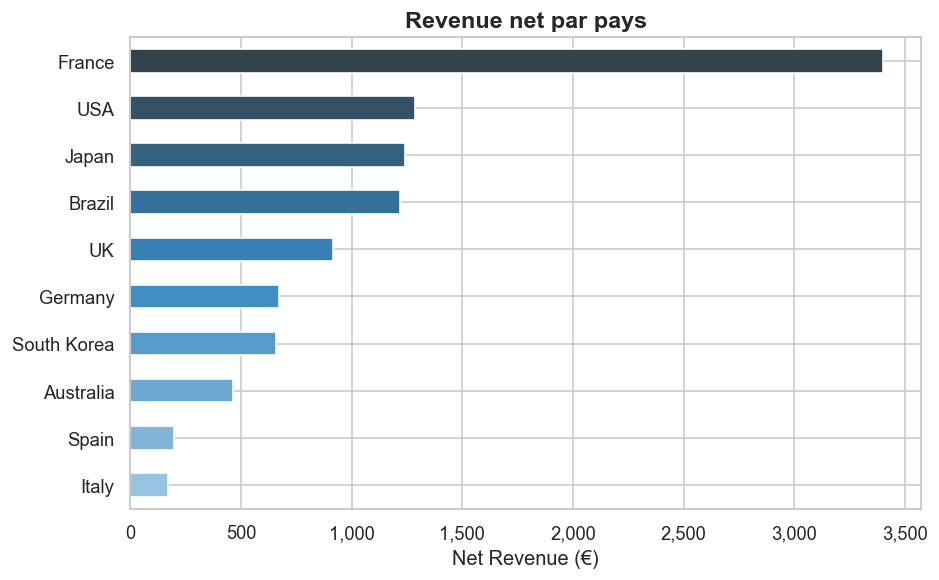

In [9]:
by_country = (
    orders.groupby("country")["net_revenue"]
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette("Blues_d", len(by_country))
by_country.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_title("Revenue net par pays", fontsize=14, fontweight="bold")
ax.set_xlabel("Net Revenue (€)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

## 8. Heatmap — Revenue net par mois × catégorie

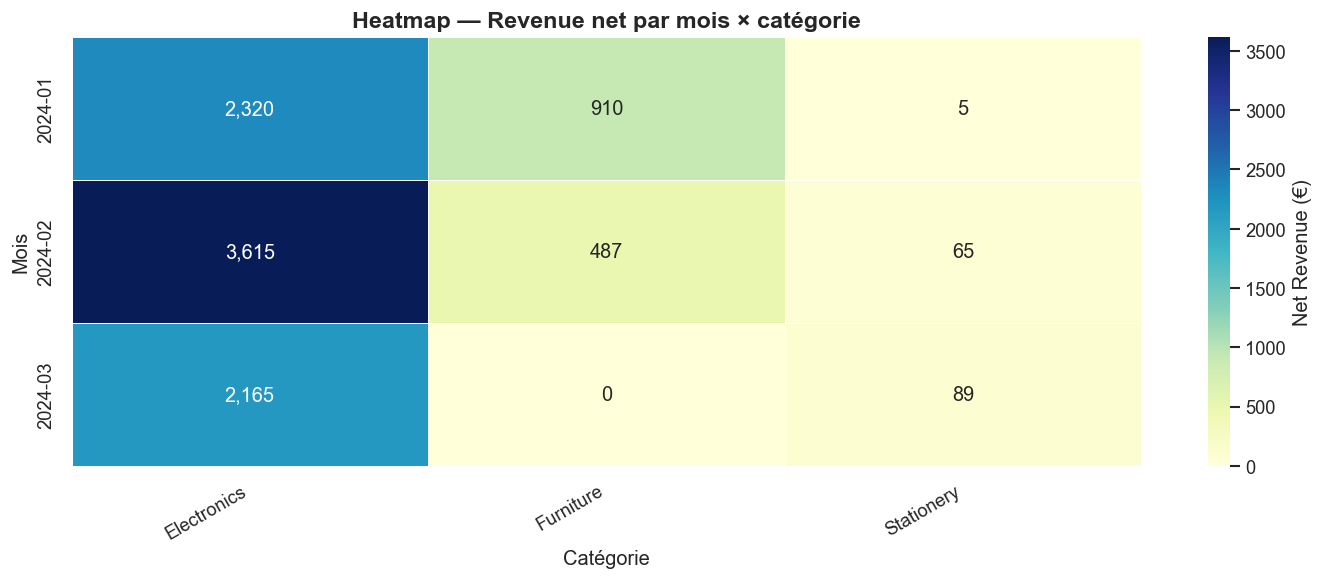

In [10]:
heat_data = summary.pivot_table(
    index="period", columns="category", values="net_revenue", aggfunc="sum"
).fillna(0)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    heat_data,
    ax=ax,
    cmap="YlGnBu",
    fmt=",.0f",
    annot=True,
    linewidths=0.5,
    cbar_kws={"label": "Net Revenue (€)"},
)
ax.set_title("Heatmap — Revenue net par mois × catégorie", fontsize=14, fontweight="bold")
ax.set_xlabel("Catégorie")
ax.set_ylabel("Mois")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()